pip install

In [1]:
!pip install selenium selenium-wire
# Install Chromium, ChromeDriver, and Selenium in Colab
!apt-get update > /dev/null
!apt install chromium-chromedriver > /dev/null
!cp /usr/lib/chromium-browser/chromedriver /usr/bin
!pip install selenium > /dev/null
# Install required packages
!pip install selenium pandas scikit-learn matplotlib -q
!apt-get update -q
!apt-get install -y chromium-chromedriver -q
!apt update
!apt install -y tshark
!pip install pyshark selenium



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


cp: '/usr/lib/chromium-browser/chromedriver' and '/usr/bin/chromedriver' are the same file
Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading

In [2]:
import sys
sys.path.insert(0, '/usr/lib/chromium-browser/chromedriver')
import os
os.environ['DISPLAY'] = ':0'

# fetching network traffic
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
import time
from urllib.parse import urlparse
import pyshark

import random
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#anomaly
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
# autoencoder
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential

import mitmproxy
from mitmproxy import http

ModuleNotFoundError: No module named 'mitmproxy'

In [ ]:

# Load CSV with columns: 'url', 'label'
df = pd.read_csv('/content/list_urls_copy.csv')  # update path if needed

df = df.dropna(subset=['url'])  # drop any rows with missing URLs
df.reset_index(drop=True, inplace=True)
display(df)

In [ ]:
# Helper function to start mitmproxy
def start_mitmproxy():
    os.system("mitmdump -s capture_traffic.py")

# MITMproxy script to capture network traffic
capture_script = '''
from mitmproxy import http

def request(flow: http.HTTPFlow):
    # Capture HTTP request
    flow.reply = http.Response.make(
        200,  # (optional) status code
        b"Hello, World",  # (optional) content
        {"Content-Type": "text/html"}  # (optional) headers
    )

def response(flow: http.HTTPFlow):
    # Capture HTTP response details
    with open("traffic_log.csv", "a") as f:
        f.write(f"{flow.request.host},{flow.request.url},{flow.response.status_code},{flow.response.content_length},{flow.response.headers}\n")
'''

# Write mitmproxy script to a file
with open("capture_traffic.py", "w") as f:
    f.write(capture_script)

In [ ]:
#@title get network ft




# def get_network_features(url):
#     chrome_options = Options()
#     chrome_options.add_argument("--headless")
#     chrome_options.add_argument("--disable-gpu")
#     chrome_options.add_argument("--no-sandbox")
#     chrome_options.add_argument("--disable-extensions")
#     chrome_options.add_argument("--window-size=1920,1080")

#     driver = webdriver.Chrome(options=chrome_options)
#     features = {}

#     try:
#         # Start packet capture (on interface eth0 or wifi0 depending on your machine)
#         capture = pyshark.LiveCapture(interface='eth0', output_file='capture.pcapng')
#         capture.sniff(timeout=15)  # async sniffing

#         # Open URL
#         start_time = time.time()
#         driver.set_page_load_timeout(15)
#         driver.get(url)
#         load_time = time.time() - start_time

#         # DOM-based features
#         features.update({
#             'load_time': load_time,
#             'dom_elements': len(driver.find_elements("xpath", "//*")),
#             'script_count': len(driver.find_elements("tag name", "script")),
#             'iframe_count': len(driver.find_elements("tag name", "iframe")),
#             'link_count': len(driver.find_elements("tag name", "a")),
#             'input_count': len(driver.find_elements("tag name", "input")),
#             'form_count': len(driver.find_elements("tag name", "form")),
#             'button_count': len(driver.find_elements("tag name", "button")),
#             'meta_count': len(driver.find_elements("tag name", "meta")),
#             'image_count': len(driver.find_elements("tag name", "img")),
#             'hidden_input_count': len([e for e in driver.find_elements("tag name", "input") if e.get_attribute("type") == "hidden"]),
#             'url_length': len(url),
#         })

#         parsed = urlparse(driver.current_url)
#         features['subdomain_length'] = len(parsed.hostname.split('.')[0]) if parsed.hostname else 0
#         features['dot_count'] = url.count('.')

#         # Stop packet capture
#         capture.close()

#         # Reopen pcap to extract traffic info
#         cap = pyshark.FileCapture('capture.pcapng')

#         packet_count = 0
#         total_bytes = 0
#         protocols = set()
#         ports = set()

#         for pkt in cap:
#             try:
#                 packet_count += 1
#                 total_bytes += int(pkt.length)
#                 protocols.add(pkt.highest_layer)
#                 if 'tcp' in pkt:
#                     ports.add(pkt.tcp.dstport)
#                 elif 'udp' in pkt:
#                     ports.add(pkt.udp.dstport)
#             except:
#                 continue

#         # Network Traffic Features
#         features.update({
#             'packet_count': packet_count,
#             'total_bytes': total_bytes,
#             'average_packet_size': total_bytes / packet_count if packet_count > 0 else 0,
#             'protocol_count': len(protocols),
#             'unique_ports_used': len(ports),
#         })

#     except Exception as e:
#         print(f"[!] Error for URL {url}: {e}")
#         # Default zero features if error occurs
#         keys = ['load_time', 'dom_elements', 'script_count', 'iframe_count', 'link_count', 'input_count',
#                 'form_count', 'button_count', 'meta_count', 'image_count', 'hidden_input_count', 'url_length',
#                 'subdomain_length', 'dot_count', 'packet_count', 'total_bytes', 'average_packet_size',
#                 'protocol_count', 'unique_ports_used']
#         features = {key: 0 for key in keys}

#     finally:
#         try:
#             driver.quit()
#         except:
#             pass

#     return features


import asyncio

async def get_selenium_driver(options):
    # This function runs the Selenium WebDriver in a separate thread to avoid event loop issues
    driver = webdriver.Chrome(options=options)
    return driver



def get_network_features(url, interface='wlan0'):
    chrome_options = Options()
    chrome_options.add_argument("--headless")
    chrome_options.add_argument("--disable-gpu")
    chrome_options.add_argument("--no-sandbox")
    chrome_options.add_argument("--disable-extensions")
    chrome_options.add_argument("--window-size=1920,1080")

    driver = await asyncio.to_thread(get_selenium_driver, chrome_options)


    # Default zero values in case of exception
    default_keys = ['load_time', 'dom_elements', 'script_count', 'iframe_count', 'link_count', 'input_count',
                    'form_count', 'button_count', 'meta_count', 'image_count', 'hidden_input_count', 'url_length',
                    'subdomain_length', 'dot_count', 'packet_count', 'total_bytes', 'average_packet_size',
                    'protocol_count', 'unique_ports_used']

    try:
        # Clean previous captures
        if os.path.exists('capture.pcapng'):
            os.remove('capture.pcapng')

        # Start network capture
        capture = pyshark.LiveCapture(interface=interface, output_file='capture.pcapng')
        capture.sniff(timeout=1)  # Prime buffer
        capture.sniff(timeout=0, packet_count=1)  # Dummy packet to trigger writing

        capture.sniff(timeout=1, packet_count=1)

        capture.start()

        # Page load
        start_time = time.time()
        driver.set_page_load_timeout(15)
        driver.get(url)
        load_time = time.time() - start_time

        # Stop network capture after load
        capture.close()

        # Extract DOM-based features
        features.update({
            'load_time': load_time,
            'dom_elements': len(driver.find_elements("xpath", "//*")),
            'script_count': len(driver.find_elements("tag name", "script")),
            'iframe_count': len(driver.find_elements("tag name", "iframe")),
            'link_count': len(driver.find_elements("tag name", "a")),
            'input_count': len(driver.find_elements("tag name", "input")),
            'form_count': len(driver.find_elements("tag name", "form")),
            'button_count': len(driver.find_elements("tag name", "button")),
            'meta_count': len(driver.find_elements("tag name", "meta")),
            'image_count': len(driver.find_elements("tag name", "img")),
            'hidden_input_count': len([e for e in driver.find_elements("tag name", "input") if e.get_attribute("type") == "hidden"]),
            'url_length': len(url),
        })

        parsed = urlparse(driver.current_url)
        features['subdomain_length'] = len(parsed.hostname.split('.')[0]) if parsed.hostname else 0
        features['dot_count'] = url.count('.')

        # Extract packet info
        cap = pyshark.FileCapture('capture.pcapng')
        packet_count = 0
        total_bytes = 0
        protocols = set()
        ports = set()

        for pkt in cap:
            try:
                packet_count += 1
                total_bytes += int(pkt.length)
                protocols.add(pkt.highest_layer)
                if hasattr(pkt, 'tcp'):
                    ports.add(pkt.tcp.dstport)
                elif hasattr(pkt, 'udp'):
                    ports.add(pkt.udp.dstport)
            except:
                continue

        features.update({
            'packet_count': packet_count,
            'total_bytes': total_bytes,
            'average_packet_size': total_bytes / packet_count if packet_count else 0,
            'protocol_count': len(protocols),
            'unique_ports_used': len(ports),
        })

    except Exception as e:
        print(f"[!] Error for URL {url}: {e}")
        features = {key: 0 for key in default_keys}

    finally:
        try:
            driver.quit()
        except:
            pass

    return features


# def get_network_features(url):
#     cchrome_options = Options()
#     chrome_options.add_argument("--headless")
#     chrome_options.add_argument("--disable-gpu")
#     chrome_options.add_argument("--no-sandbox")
#     chrome_options.add_argument("--disable-extensions")
#     chrome_options.add_argument("--disable-infobars")
#     chrome_options.add_argument("--disable-popup-blocking")
#     chrome_options.add_argument("--window-size=1920,1080")
#     driver = webdriver.Chrome(options=chrome_options)
#     features = {}

#     try:
#         # Page load time
#         start_time = time.time()
#         driver.set_page_load_timeout(15)
#         driver.get(url)
#         load_time = time.time() - start_time

#         # DOM-based features
#         dom_elements = driver.find_elements("xpath", "//*")
#         scripts = driver.find_elements("tag name", "script")
#         iframes = driver.find_elements("tag name", "iframe")
#         links = driver.find_elements("tag name", "a")
#         forms = driver.find_elements("tag name", "form")
#         inputs = driver.find_elements("tag name", "input")
#         buttons = driver.find_elements("tag name", "button")
#         metas = driver.find_elements("tag name", "meta")
#         images = driver.find_elements("tag name", "img")
#         spans = driver.find_elements("tag name", "span")
#         hidden_inputs = [e for e in inputs if e.get_attribute("type") == "hidden"]


#         # Extract URL metadata
#         parsed_url = urlparse(driver.current_url)
#         hostname = parsed_url.hostname or ''
#         dot_count = hostname.count(".")
#         subdomain_len = len(hostname.split('.')[0]) if dot_count > 1 else 0

#         # Assign extracted features
#         features = {
#             'load_time': load_time,
#             'dom_elements': len(dom_elements),
#             'script_count': len(scripts),
#             'iframe_count': len(iframes),
#             'link_count': len(links),
#             'input_count': len(inputs),
#             'form_count': len(forms),
#             'button_count': len(buttons),
#             'meta_count': len(metas),
#             'image_count': len(images),
#             'span_count': len(spans),
#             'hidden_input_count': len(hidden_inputs),
#             'subdomain_length': subdomain_len,
#             'dot_count': dot_count,
#             'url_length': len(url),
#         }

#     except Exception as e:
#         print(f"[!] Error for URL {url}: {e}")
#         features = {key: 0 for key in [
#             'load_time', 'dom_elements', 'script_count', 'iframe_count', 'link_count',
#             'input_count', 'form_count', 'button_count', 'meta_count', 'image_count',
#             'span_count', 'hidden_input_count', 'subdomain_length', 'dot_count', 'url_length'
#         ]}

#     finally:
#         try:
#             driver.quit()
#         except Exception as quit_e:
#             print(f"[!] Error while closing driver for {url}: {quit_e}")

#     return features



In [ ]:
def sanitize_url(url):
    if not url.startswith(('http:', 'https:')):
        return 'http://' + url
    return url
# def sanitize_url(url):
#     parsed_url = urlparse(url)
#     if not parsed_url.scheme:
#         return f"http://{url}"  # Add http:// if no scheme is provided
#     return url


In [ ]:
check= df.copy()
check['url'] = check['url'].apply(sanitize_url)
check.dropna(subset=['url'], inplace=True)
check.reset_index(drop=True, inplace=True)
display(check)


In [ ]:
#@title network ft extr
# sample_df = df.sample(n=50, random_state=42).reset_index(drop=True)
# network_features = []

# # Loop through sampled URLs
# for i, row in sample_df.iterrows():
#     url = row['url']
#     print(f"[{i+1}/{len(sample_df)}] Trying: {url}")

#     try:
#         feats = get_network_features(url)
#         network_features.append(feats)
#     except Exception as e:
#         print(f"[!] Error for URL {url}: {e}")
#         # If error occurs, skip this iteration and continue with the next URL
#         continue

# # Convert to DataFrame
# network_df = pd.DataFrame(network_features)

# # Combine extracted features with sampled data
# full_df = pd.concat([sample_df, network_df], axis=1)

# # Convert to DataFrame
# network_df = pd.DataFrame(network_features)

# # Combine extracted features with sampled data
# full_df = pd.concat([sample_df, network_df], axis=1)



target_count = 100
collected = 0
max_attempts = 1000
attempts = 0

valid_rows = []
network_features = []

# Shuffle and iterate through random URLs
url_indices = df.sample(frac=1, random_state=42).index.tolist()

for idx in url_indices:
    if collected >= target_count or attempts >= max_attempts:
        break

    row = df.loc[idx]
    url = sanitize_url(row['url'])
    print(f"[{collected+1}/{target_count}] Trying: {url}")

    try:
        feats =  get_network_features(url)
        network_features.append(feats)
        valid_rows.append(row)
        collected += 1
    except Exception as e:
        print(f"[!] Skipped due to error: {url}\n{e}")

    attempts += 1

# Final merged DataFrame
valid_df = pd.DataFrame(valid_rows).reset_index(drop=True)
network_df = pd.DataFrame(network_features)
full_df = pd.concat([valid_df, network_df], axis=1)

print("\n✅ Successfully extracted features for valid URLs.")

[1/100] Trying: http://37.49.226.178/deusbins/deus.sh4
[!] Error for URL http://37.49.226.178/deusbins/deus.sh4: This event loop is already running
[!] Skipped due to error: http://37.49.226.178/deusbins/deus.sh4
object dict can't be used in 'await' expression
[1/100] Trying: http://medical-dictionary.thefreedictionary.com/Galt+trephine


<ipython-input-38-a70242026775>:193: RuntimeWarning: coroutine 'wait_for' was never awaited
  features = {key: 0 for key in default_keys}
<ipython-input-38-a70242026775>:193: RuntimeWarning: coroutine 'Capture.packets_from_tshark' was never awaited
  features = {key: 0 for key in default_keys}


[!] Error for URL http://medical-dictionary.thefreedictionary.com/Galt+trephine: This event loop is already running
[!] Skipped due to error: http://medical-dictionary.thefreedictionary.com/Galt+trephine
object dict can't be used in 'await' expression
[1/100] Trying: http://www.jscape.com/sshfactory/
[!] Error for URL http://www.jscape.com/sshfactory/: This event loop is already running
[!] Skipped due to error: http://www.jscape.com/sshfactory/
object dict can't be used in 'await' expression
[1/100] Trying: http://www.wsnc.org.au/component/jcalpro/view/983
[!] Error for URL http://www.wsnc.org.au/component/jcalpro/view/983: This event loop is already running
[!] Skipped due to error: http://www.wsnc.org.au/component/jcalpro/view/983
object dict can't be used in 'await' expression
[1/100] Trying: http://virtualtourist.com/travel/North_America/Canada/Province_of_Quebec/Montreal-906413/Transportation-Montreal-Train-BR-2.html
[!] Error for URL http://virtualtourist.com/travel/North_Americ

Exception ignored when trying to write to the signal wakeup fd:
Traceback (most recent call last):
  File "/usr/lib/python3.11/asyncio/unix_events.py", line 42, in _sighandler_noop
    def _sighandler_noop(signum, frame):
    
BlockingIOError: [Errno 11] Resource temporarily unavailable
Exception ignored when trying to write to the signal wakeup fd:
Traceback (most recent call last):
  File "/usr/lib/python3.11/asyncio/unix_events.py", line 42, in _sighandler_noop
    def _sighandler_noop(signum, frame):
    
BlockingIOError: [Errno 11] Resource temporarily unavailable
Exception ignored when trying to write to the signal wakeup fd:
Traceback (most recent call last):
  File "/usr/lib/python3.11/asyncio/unix_events.py", line 42, in _sighandler_noop
    def _sighandler_noop(signum, frame):
    
BlockingIOError: [Errno 11] Resource temporarily unavailable


[!] Error for URL http://en.wikipedia.org/wiki/Francois_Arnaud: This event loop is already running
[!] Skipped due to error: http://en.wikipedia.org/wiki/Francois_Arnaud
object dict can't be used in 'await' expression
[1/100] Trying: http://whosdatedwho.com/tpx_50191/yanic-truesdale/


...

[!] Skipped due to error: http://last.fm/music/Hope+Sandoval/Bavarian+Fruit+Bread
('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
[1/100] Trying: http://lawyerintl.com/attorney-98426-Burnes%20&%20Libman/
[!] Skipped due to error: http://lawyerintl.com/attorney-98426-Burnes%20&%20Libman/
Message: Unable to obtain driver for chrome; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors/driver_location

[1/100] Trying: http://www.itworld.com/swol-0818-regex
[!] Skipped due to error: http://www.itworld.com/swol-0818-regex
Message: Unable to obtain driver for chrome; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors/driver_location

[1/100] Trying: http://facebook.com/pages/Agence-Jacky-Hangard-immobilier-Clermont-oise/123500497720606
[!] Skipped due to error: http://facebook.com/pages/Agence-Jacky-Hangard-immobili

Exception ignored when trying to write to the signal wakeup fd:
Traceback (most recent call last):
  File "/usr/lib/python3.11/asyncio/unix_events.py", line 42, in _sighandler_noop
    def _sighandler_noop(signum, frame):
    
BlockingIOError: [Errno 11] Resource temporarily unavailable
Exception ignored when trying to write to the signal wakeup fd:
Traceback (most recent call last):
  File "/usr/lib/python3.11/asyncio/unix_events.py", line 42, in _sighandler_noop
    def _sighandler_noop(signum, frame):
    
BlockingIOError: [Errno 11] Resource temporarily unavailable
Exception ignored when trying to write to the signal wakeup fd:
Traceback (most recent call last):
  File "/usr/lib/python3.11/asyncio/unix_events.py", line 42, in _sighandler_noop
    def _sighandler_noop(signum, frame):
    
BlockingIOError: [Errno 11] Resource temporarily unavailable


[!] Skipped due to error: http://sheridan.com/about/our-companies/sheridan-press/key-contacts
('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
[1/100] Trying: http://aavad.com/artistbibliog.cfm?id=54


Exception ignored when trying to write to the signal wakeup fd:
Traceback (most recent call last):
  File "/usr/lib/python3.11/asyncio/unix_events.py", line 42, in _sighandler_noop
    def _sighandler_noop(signum, frame):
    
BlockingIOError: [Errno 11] Resource temporarily unavailable
Exception ignored when trying to write to the signal wakeup fd:
Traceback (most recent call last):
  File "/usr/lib/python3.11/asyncio/unix_events.py", line 42, in _sighandler_noop
    def _sighandler_noop(signum, frame):
    
BlockingIOError: [Errno 11] Resource temporarily unavailable


[!] Skipped due to error: http://aavad.com/artistbibliog.cfm?id=54
('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
[1/100] Trying: http://one21music.com/2011/03/american-idol-top-13-power-rankings/


In [ ]:
display(full_df)

In [ ]:
#@title anomaly detection
selected_features = ['load_time', 'dom_elements', 'script_count', 'iframe_count',
                     'link_count', 'input_count', 'form_count', 'packet_count',
                     'total_bytes', 'average_packet_size', 'protocol_count', 'unique_ports_used']

X = full_df[selected_features].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest for anomaly detection
model = IsolationForest(contamination=0.1, random_state=42)
preds = model.fit_predict(X_scaled)

# Label: 1 = normal, -1 = anomaly → convert to binary
full_df['threat_score'] = np.where(preds == -1, 1, 0)

In [ ]:
#@title anomaly detection on models
y_true = full_df['label'].values

# ------ ISOLATION FOREST ------
iso = IsolationForest(contamination=0.1, random_state=42)
iso_pred = iso.fit_predict(X_scaled)
iso_pred = np.where(iso_pred == -1, 1, 0)
iso_acc = accuracy_score(y_true, iso_pred)
print(f"[Isolation Forest] Accuracy: {iso_acc:.4f}")
print(classification_report(y_true, iso_pred))

# ------ ONE-CLASS SVM ------
ocsvm = OneClassSVM(nu=0.1, kernel="rbf", gamma='scale')
ocsvm.fit(X_scaled)
svm_pred = ocsvm.predict(X_scaled)
svm_pred = np.where(svm_pred == -1, 1, 0)
svm_acc = accuracy_score(y_true, svm_pred)
print(f"\n[One-Class SVM] Accuracy: {svm_acc:.4f}")
print(classification_report(y_true, svm_pred))

# ------ DBSCAN ------
db = DBSCAN(eps=1.5, min_samples=5)
db_labels = db.fit_predict(X_scaled)
# Convert DBSCAN output: noise points (-1) → 1 (anomaly), else 0
db_pred = np.where(db_labels == -1, 1, 0)
db_acc = accuracy_score(y_true, db_pred)
print(f"\n[DBSCAN] Accuracy: {db_acc:.4f}")
print(classification_report(y_true, db_pred))

# ------ AUTOENCODER ------
input_dim = X_scaled.shape[1]
autoencoder = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(input_dim, activation='linear')
])
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder.fit(X_scaled, X_scaled, epochs=30, batch_size=8, verbose=0)

# Reconstruction error
reconstructions = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - reconstructions, 2), axis=1)

# Threshold based on percentile (e.g. 90th percentile)
threshold = np.percentile(mse, 90)
ae_pred = np.where(mse > threshold, 1, 0)
ae_acc = accuracy_score(y_true, ae_pred)
print(f"\n[Autoencoder] Accuracy: {ae_acc:.4f}")
print(classification_report(y_true, ae_pred))



# # One-Class SVM
# svm_model = OneClassSVM(gamma='scale', nu=0.05)
# svm_preds = svm_model.fit_predict(X_scaled)
# full_df['svm_anomaly'] = [1 if x == -1 else 0 for x in svm_preds]

# # Isolation Forest
# iso_model = IsolationForest(contamination=0.05, random_state=42)
# iso_preds = iso_model.fit_predict(X_scaled)
# full_df['isolation_anomaly'] = [1 if x == -1 else 0 for x in iso_preds]

# # DBSCAN
# db_model = DBSCAN(eps=1.5, min_samples=5)
# db_labels = db_model.fit_predict(X_scaled)
# full_df['dbscan_anomaly'] = [1 if label == -1 else 0 for label in db_labels]

# # Final threat score (any anomaly = phishing)
# full_df['threat_score'] = full_df[['svm_anomaly', 'isolation_anomaly', 'dbscan_anomaly']].max(axis=1)



📌 [Isolation Forest]
Accuracy:  0.7000


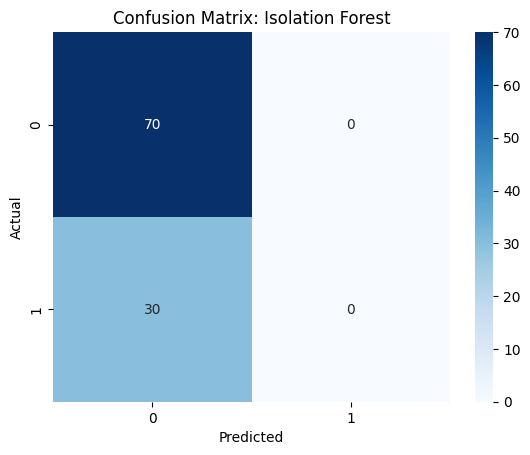


📌 [One-Class SVM]
Accuracy:  0.3000


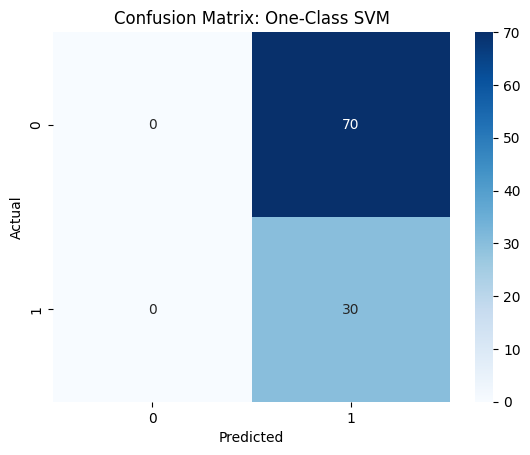


📌 [DBSCAN]
Accuracy:  0.7000


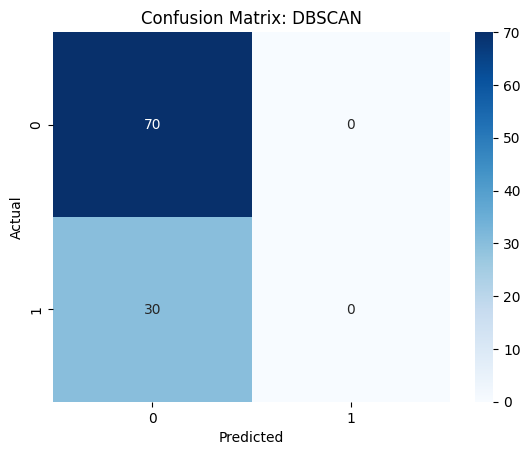


📌 [Autoencoder]
Accuracy:  0.7000


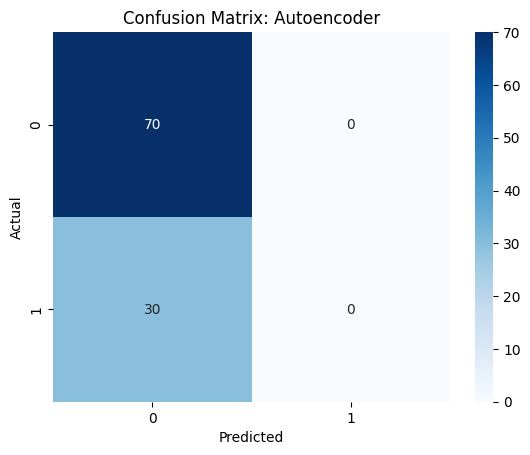

In [45]:
#@title eval models
# # Clean if 'label' is float
# full_df['label'] = full_df['label'].astype(int)

from sklearn.metrics import confusion_matrix, classification_report

# print("🔍 Accuracy:", accuracy_score(full_df['label'], full_df['threat_score']))
# print(classification_report(full_df['label'], full_df['threat_score']))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

# cm = confusion_matrix(full_df['label'], full_df['threat_score'])
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix - Threat Score vs Label")
# plt.show()

def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    # prec = precision_score(y_true, y_pred, zero_division=0)
    # rec = recall_score(y_true, y_pred, zero_division=0)
    # f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n📌 [{model_name}]")
    print(f"Accuracy:  {acc:.4f}")
    # print(f"Precision: {prec:.4f}")
    # print(f"Recall:    {rec:.4f}")
    # print(f"F1-score:  {f1:.4f}")

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

evaluate_model(y_true, iso_pred, "Isolation Forest")
evaluate_model(y_true, svm_pred, "One-Class SVM")
evaluate_model(y_true, db_pred, "DBSCAN")
evaluate_model(y_true, ae_pred, "Autoencoder")


In [46]:
full_df.to_csv('/content/phishing_network_labeled.csv', index=False)
print("✅ File saved as phishing_network_labeled.csv")


✅ File saved as phishing_network_labeled.csv


# ***TESTING***

In [27]:
!pip install adversarial-robustness-toolbox --quiet
!pip install --upgrade adversarial-robustness-toolbox



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 25.8 MB/s eta 0:00:00


In [28]:
import random
import string

def generate_adversarial_url(url):
    # Add random subdomain
    subdomain = ''.join(random.choices(string.ascii_lowercase, k=5))
    if "://" in url:
        protocol, rest = url.split("://", 1)
        rest_parts = rest.split("/", 1)
        domain = rest_parts[0]
        path = rest_parts[1] if len(rest_parts) > 1 else ""
        new_url = f"{protocol}://{subdomain}.{domain}/{path}?utm_source=ph1sh&ref=click123"
    else:
        new_url = f"http://{subdomain}.{url}/?fakeparam=true"

    # Homoglyph attack
    new_url = new_url.replace("o", "0").replace("i", "1").replace("e", "3")
    return new_url


In [29]:
phishing_urls = full_df[full_df['label'] == 1]['url'].tolist()
adversarial_urls = [generate_adversarial_url(url) for url in phishing_urls[:30]]


In [30]:
adversarial_features = []

for i, url in enumerate(adversarial_urls):
    print(f"[{i+1}/{len(adversarial_urls)}] Testing adversarial URL: {url}")
    try:
        feats = get_network_features(url)
        adversarial_features.append(feats)
    except Exception as e:
        print(f"[!] Skipped {url} due to error:\n{e}")


[1/30] Testing adversarial URL: http://aqanj.37.49.226.178/d3usb1ns/d3us.sh4?utm_s0urc3=ph1sh&r3f=cl1ck123
[!] Error for URL http://aqanj.37.49.226.178/d3usb1ns/d3us.sh4?utm_s0urc3=ph1sh&r3f=cl1ck123: This event loop is already running
[2/30] Testing adversarial URL: http://snr0n.www.jscap3.c0m/sshfact0ry//?fak3param=tru3


<ipython-input-11-a9c84487b4ec>:87: RuntimeWarning: coroutine 'wait_for' was never awaited
  features = {key: 0 for key in keys}
<ipython-input-11-a9c84487b4ec>:87: RuntimeWarning: coroutine 'Capture.packets_from_tshark' was never awaited
  features = {key: 0 for key in keys}


[!] Error for URL http://snr0n.www.jscap3.c0m/sshfact0ry//?fak3param=tru3: This event loop is already running
[3/30] Testing adversarial URL: http://zxybc.www.wsnc.0rg.au/c0mp0n3nt/jcalpr0/v13w/983?utm_s0urc3=ph1sh&r3f=cl1ck123
[!] Error for URL http://zxybc.www.wsnc.0rg.au/c0mp0n3nt/jcalpr0/v13w/983?utm_s0urc3=ph1sh&r3f=cl1ck123: This event loop is already running
[4/30] Testing adversarial URL: http://d0hzp.www.sw33th0m3.c0m.gr/1nd3x.php?0pt10n=c0m_3stat3ag3nt&act=cat&task=sh0wCE&1d=9?utm_s0urc3=ph1sh&r3f=cl1ck123
[!] Error for URL http://d0hzp.www.sw33th0m3.c0m.gr/1nd3x.php?0pt10n=c0m_3stat3ag3nt&act=cat&task=sh0wCE&1d=9?utm_s0urc3=ph1sh&r3f=cl1ck123: This event loop is already running
[5/30] Testing adversarial URL: http://wrhzt.www.msnbc.msn.c0m/?1d=3475953/?fak3param=tru3
[!] Error for URL http://wrhzt.www.msnbc.msn.c0m/?1d=3475953/?fak3param=tru3: This event loop is already running
[6/30] Testing adversarial URL: http://kzvrv.www.mrun1qu3spav1ng.c0.uk/pav3d-dr1v3way-gall3ry?utm_

In [36]:
adv_df = pd.DataFrame(adversarial_features)
X_adv = adv_df[selected_features].values  # Make sure to use same selected features
X_adv_scaled = scaler.transform(X_adv)

# Predict using all models
iso_adv_pred = iso.fit_predict(X_adv_scaled)
svm_adv_pred = ocsvm.predict(X_adv_scaled)
db_adv_pred = db.fit_predict(X_adv_scaled)
ae_adv_pred = autoencoder.predict(X_adv_scaled)

# Convert to labels
iso_adv_labels = np.where(iso_adv_pred == -1, 1, 0)
svm_adv_labels = np.where(svm_adv_pred == -1, 1, 0)
db_adv_labels = np.where(db_adv_pred == -1, 1, 0)
ae_adv_labels = (ae_adv_pred > threshold).astype(int)  # use same threshold as earlier








1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step



📌 [Adversarial - Isolation Forest]
Accuracy:  0.0000


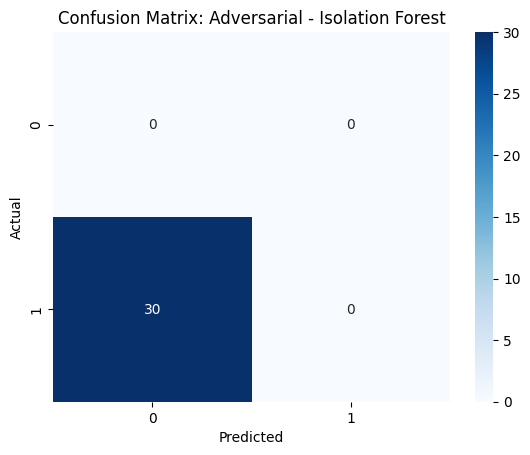

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



📌 [Adversarial - One-Class SVM]
Accuracy:  1.0000


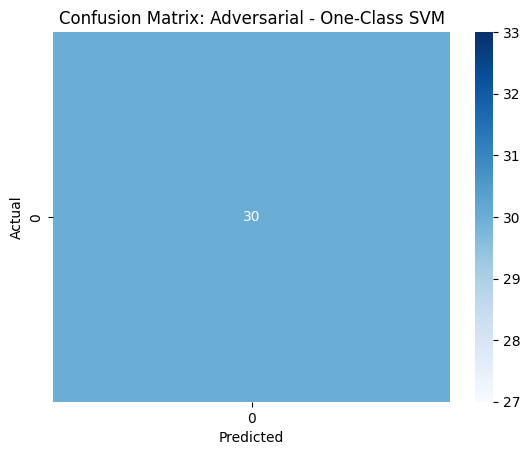


📌 [Adversarial - DBSCAN]
Accuracy:  0.0000


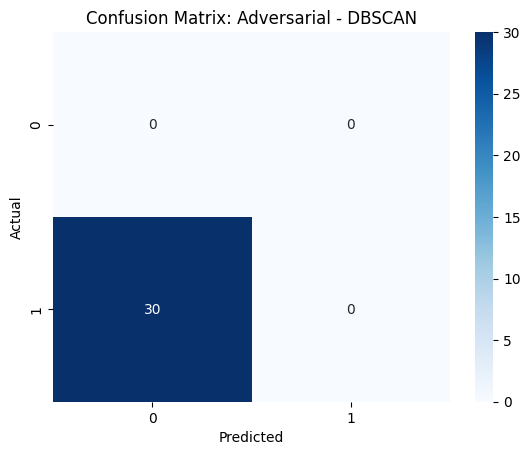

ValueError: Classification metrics can't handle a mix of binary and multilabel-indicator targets

In [37]:
y_adv_true = np.ones(len(adversarial_urls))

evaluate_model(y_adv_true, iso_adv_labels, "Adversarial - Isolation Forest")
evaluate_model(y_adv_true, svm_adv_labels, "Adversarial - One-Class SVM")
evaluate_model(y_adv_true, db_adv_labels, "Adversarial - DBSCAN")
evaluate_model(y_adv_true, ae_adv_labels, "Adversarial - Autoencoder")
